In [1]:
#Task3: Gaussian Mixture Model
#Step1: Step 1: Create Two Clusters
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import multivariate_normal

np.random.seed(42)

# Cluster 1
mean1 = [4.5, 1.8]
cov1 = [[0.2, 0.05],
        [0.05, 0.1]]

data1 = np.random.multivariate_normal(mean1, cov1, 100)

# Cluster 2
mean2 = [6.0, 2.5]
cov2 = [[0.3, -0.04],
        [-0.04, 0.2]]

data2 = np.random.multivariate_normal(mean2, cov2, 100)

# Combine
X = np.vstack((data1, data2))


In [2]:
#means → centers of clusters (high usage / low usage houses)

#covariances → spread of clusters

#weights → probability of each cluster
# We start with random guesses.


k = 2  # number of clusters

n, d = X.shape  # n samples, d features

# Initial means
means = X[np.random.choice(n, k, replace=False)]

# Initial covariance matrices
covariances = [np.cov(X.T) for _ in range(k)]

# Initial mixing coefficients
weights = np.ones(k) / k


# Plots for different iterations

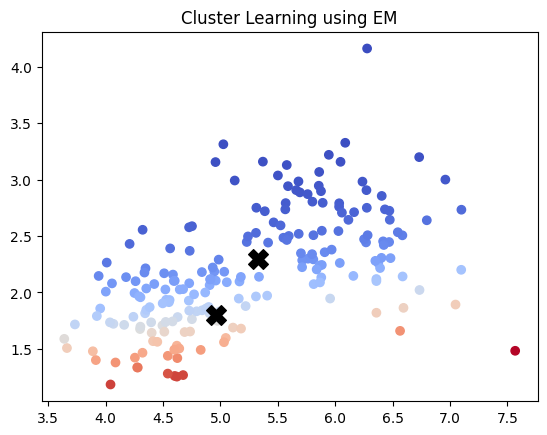

Means:
 [[4.9633731  1.80126726]
 [5.32423324 2.29818696]]
Covariances:
 [array([[0.76218528, 0.15225436],
       [0.15225436, 0.13326418]]), array([[0.68356607, 0.22655747],
       [0.22655747, 0.23409549]])]
Weights:
 [0.22665726 0.77334274]


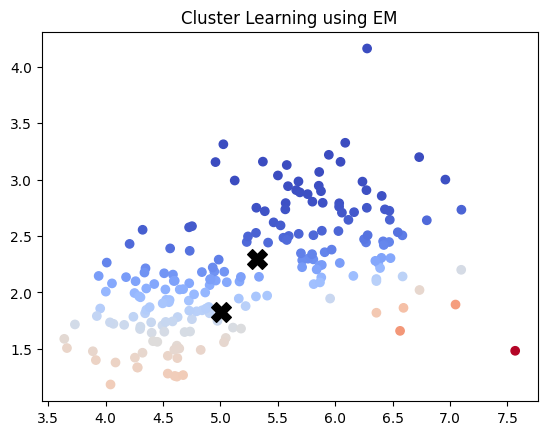

Means:
 [[5.00162794 1.82305168]
 [5.31517092 2.29503824]]
Covariances:
 [array([[0.84396031, 0.13041769],
       [0.13041769, 0.10927721]]), array([[0.6652414 , 0.24026261],
       [0.24026261, 0.24671676]])]
Weights:
 [0.23195943 0.76804057]


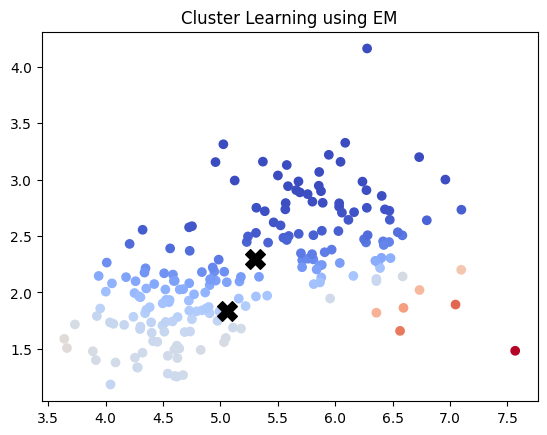

Means:
 [[5.05392898 1.83926422]
 [5.30045251 2.29212072]]
Covariances:
 [array([[0.91578968, 0.12142402],
       [0.12142402, 0.09876865]]), array([[0.65095581, 0.25171964],
       [0.25171964, 0.25419618]])]
Weights:
 [0.23531564 0.76468436]


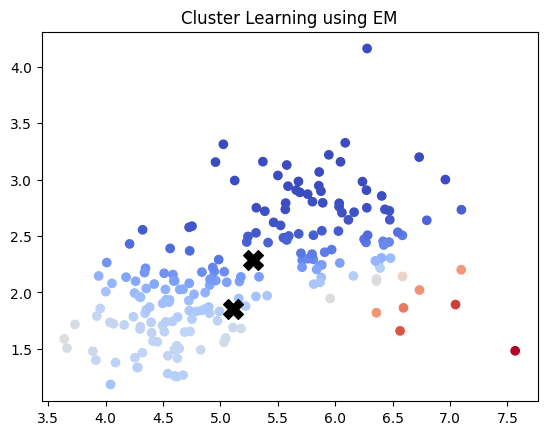

Means:
 [[5.10963079 1.85602582]
 [5.28325107 2.28681289]]
Covariances:
 [array([[0.96531768, 0.12000786],
       [0.12000786, 0.09430737]]), array([[0.6430399 , 0.26079079],
       [0.26079079, 0.26013457]])]
Weights:
 [0.23504973 0.76495027]


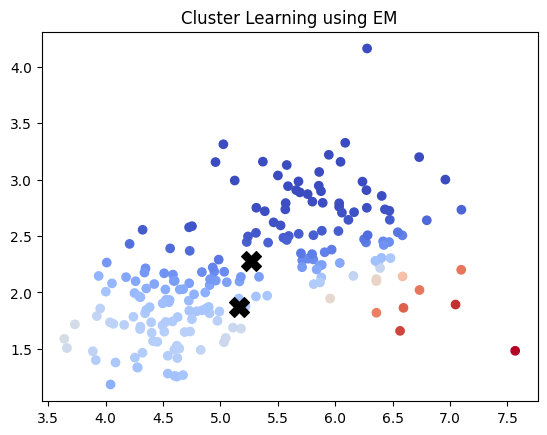

Means:
 [[5.16408269 1.87366856]
 [5.26615185 2.27992885]]
Covariances:
 [array([[0.99761938, 0.12128736],
       [0.12128736, 0.09286007]]), array([[0.63906206, 0.2677831 ],
       [0.2677831 , 0.26510123]])]
Weights:
 [0.23229528 0.76770472]


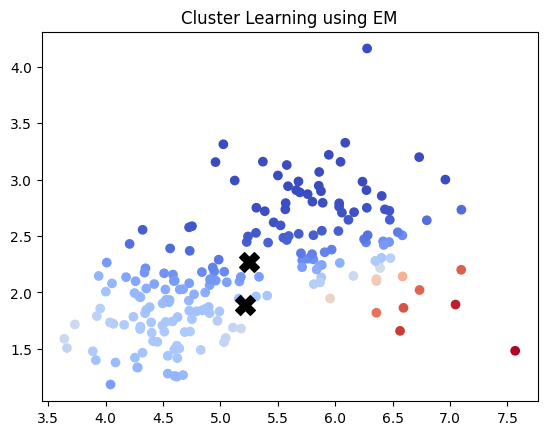

Means:
 [[5.21650045 1.89168895]
 [5.25011577 2.27249041]]
Covariances:
 [array([[1.01920739, 0.12278725],
       [0.12278725, 0.09287353]]), array([[0.63668537, 0.27323965],
       [0.27323965, 0.26924001]])]
Weights:
 [0.22829194 0.77170806]


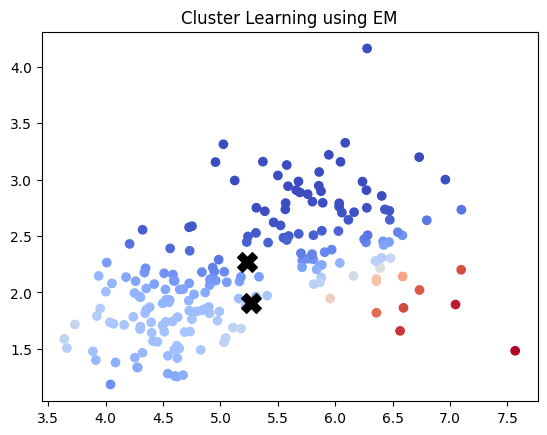

Means:
 [[5.26715214 1.90975444]
 [5.23531695 2.26507793]]
Covariances:
 [array([[1.03372888, 0.12361805],
       [0.12361805, 0.0935588 ]]), array([[0.63474172, 0.27756643],
       [0.27756643, 0.27267894]])]
Weights:
 [0.22380009 0.77619991]


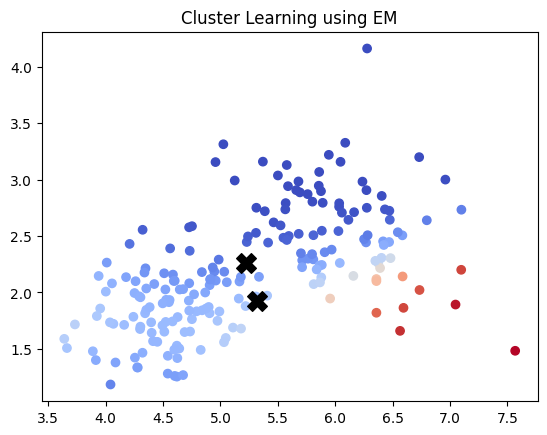

Means:
 [[5.31640583 1.92770365]
 [5.2216728  2.25796064]]
Covariances:
 [array([[1.042804  , 0.12353189],
       [0.12353189, 0.09452228]]), array([[0.63278393, 0.28103292],
       [0.28103292, 0.27553995]])]
Weights:
 [0.21923576 0.78076424]


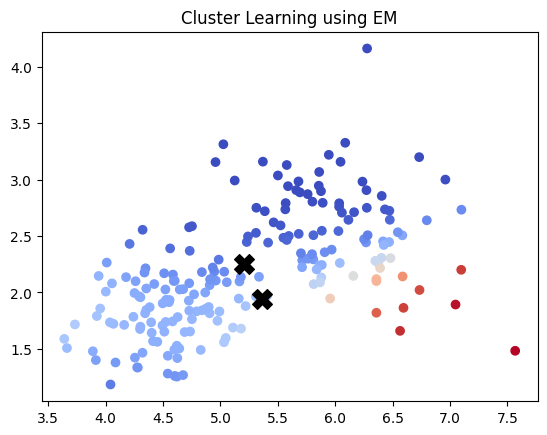

Means:
 [[5.36452179 1.94545894]
 [5.20904016 2.25124795]]
Covariances:
 [array([[1.04710815, 0.12250171],
       [0.12250171, 0.09556892]]), array([[0.63067218, 0.2838235 ],
       [0.2838235 , 0.27792691]])]
Weights:
 [0.21482606 0.78517394]


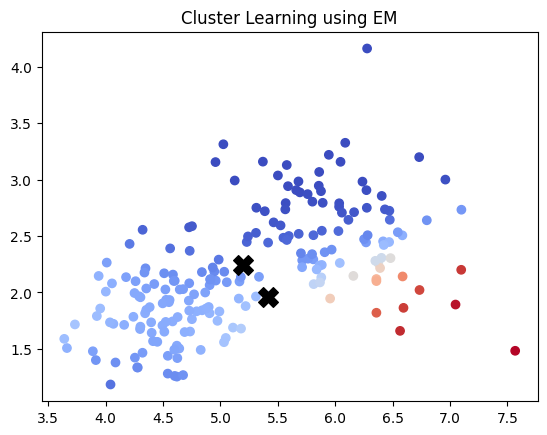

Means:
 [[5.41166107 1.96298464]
 [5.19727039 2.24496963]]
Covariances:
 [array([[1.04694581, 0.12057202],
       [0.12057202, 0.09660361]]), array([[0.62837634, 0.28607175],
       [0.28607175, 0.27992553]])]
Weights:
 [0.21069606 0.78930394]


In [3]:
for iters in range(1, 5):
    means_init = means.copy()
    covariances_init = [c.copy() for c in covariances]
    weights_init = weights.copy()


    for step in range(iters):

        # E-step
        responsibilities = np.zeros((n, k))
        for i in range(k):
            rv = multivariate_normal(means[i], covariances[i])
            responsibilities[:, i] = weights[i] * rv.pdf(X)
        responsibilities /= responsibilities.sum(axis=1, keepdims=True)

        # M-step
        Nk = responsibilities.sum(axis=0)
        weights = Nk / n
        means = np.dot(responsibilities.T, X) / Nk[:, np.newaxis]

        covariances = []
        for i in range(k):
            diff = X - means[i]
            cov = np.dot(responsibilities[:, i] * diff.T, diff) / Nk[i]
            covariances.append(cov)

        plt.scatter(X[:,0], X[:,1], c=responsibilities[:,0], cmap='coolwarm')
        plt.scatter(means[:,0], means[:,1], c='black', marker='X', s=200)
        plt.title("Cluster Learning using EM")
        plt.show()
        print("Means:\n", means)
        print("Covariances:\n", covariances)
        print("Weights:\n", weights)